Install Dependencies

In [ ]:
!pip install networkx matplotlib pandas sentence-transformers pydantic

Imports

In [ ]:
from __future__ import annotations

from typing import List, Dict, Tuple, Optional, Any

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pydantic import BaseModel, Field
from sentence_transformers import SentenceTransformer

Core Data Models

In [ ]:
# Install once if needed
# !pip -q install networkx pydantic numpy sentence-transformers

from __future__ import annotations
from typing import List, Dict, Tuple, Optional, Any
from pydantic import BaseModel, Field
import networkx as nx
import numpy as np
from sentence_transformers import SentenceTransformer

# ----------------------------
# Canonical claim model
# ----------------------------
class Claim(BaseModel):
    """
    Canonical semantic claim representation.

    Claims may be extracted or aligned with LLM assistance during semantic
    projection, but LLM outputs are not treated as authoritative ground truth.
    Instead, the framework operates over structured claims together with
    attached evidence and provenance for downstream comparison, auditing,
    and constraint-aware drift analysis.
    """
    s: str
    p: str
    o: str
    q: Dict[str, Any] = Field(default_factory=dict)
    gamma: float = 1.0
    evidence: List[str] = Field(default_factory=list)
    provenance: Dict[str, Any] = Field(default_factory=dict)

    def key(self) -> Tuple[str, str, Tuple[Tuple[str, Any], ...]]:
        """
        Returns a stable key used to align claims across artifacts.
        The key excludes the object so that object changes are captured
        as MODIFIED transitions rather than remove/add pairs.
        """
        return (self.s, self.p, tuple(sorted(self.q.items())))


class ClaimSet(BaseModel):
    claims: List[Claim] = Field(default_factory=list)

    def by_key(self) -> Dict[Tuple, Claim]:
        return {c.key(): c for c in self.claims}


# ----------------------------
# Delta model
# ----------------------------
class ClaimDelta(BaseModel):
    """
    Semantic delta between two aligned ClaimSets.
    """
    added: List[Claim] = Field(default_factory=list)
    removed: List[Claim] = Field(default_factory=list)
    modified: List[Tuple[Claim, Claim]] = Field(default_factory=list)
    provenance: Dict[str, Any] = Field(default_factory=dict)


# ----------------------------
# Constraint / event models
# ----------------------------
class SIC(BaseModel):
    """
    Safety Integrity Constraint used to scope and evaluate drift.
    """
    id: str
    description: str
    predicates: Optional[List[str]] = None
    subjects: Optional[List[str]] = None
    epsilon: float = 0.2
    lambda_p: float = 0.5
    w_p: float = 1.0


class DriftCandidate(BaseModel):
    """
    Intermediate record for a candidate drift event prior to scoring
    and explanation generation.
    """
    source: str
    target: str
    constraint_id: str
    result: str
    delta: ClaimDelta


class DriftEvent(BaseModel):
    """
    Final drift event emitted by the detector.
    """
    source: str
    target: str
    constraint_id: str
    severity: float
    drift_type: str
    explanation: str


# ----------------------------
# Graph helpers
# ----------------------------
def normalize_artifact(artifact: Dict[str, Any]) -> Dict[str, Any]:
    """
    Normalize an artifact into the expected intermediate representation.
    This placeholder currently passes the artifact through unchanged.
    """
    return artifact


def project_semantic_claims(v_norm: Dict[str, Any]) -> ClaimSet:
    """
    Project an artifact into the canonical semantic claim representation.

    This function is the semantic projection boundary of the framework.
    Projection may be assisted by LLM-based extraction, normalization, or
    alignment, but LLM outputs are not treated as trusted sources of truth.
    Downstream reasoning operates over the resulting structured claims
    together with their evidence and provenance.
    """
    return ClaimSet(claims=[Claim(**c) for c in v_norm.get("claims", [])])


def align_and_diff(Ci: ClaimSet, Cj: ClaimSet) -> ClaimDelta:
    """
    Align two ClaimSets by stable claim key and compute their semantic delta.
    """
    mi, mj = Ci.by_key(), Cj.by_key()
    keys_i, keys_j = set(mi.keys()), set(mj.keys())

    added = [mj[k] for k in sorted(keys_j - keys_i)]
    removed = [mi[k] for k in sorted(keys_i - keys_j)]

    modified = []
    for k in sorted(keys_i & keys_j):
        old, new = mi[k], mj[k]
        if old.o != new.o:
            modified.append((old, new))

    return ClaimDelta(added=added, removed=removed, modified=modified)


def attach_provenance(delta: ClaimDelta, e_ij: Dict[str, Any]) -> ClaimDelta:
    """
    Attach edge-level provenance metadata to a computed delta.
    """
    delta.provenance = dict(e_ij)
    return delta


def update_graph_node(
    G: nx.DiGraph,
    node_id: str,
    claims: ClaimSet,
    meta: Optional[Dict[str, Any]] = None
):
    """
    Insert or update a graph node with its associated ClaimSet and metadata.
    """
    G.add_node(node_id)
    G.nodes[node_id]["claims"] = claims
    if meta:
        G.nodes[node_id].update(meta)


def update_graph_edge(
    G: nx.DiGraph,
    src: str,
    dst: str,
    delta: ClaimDelta,
    meta: Optional[Dict[str, Any]] = None
):
    """
    Insert or update a directed graph edge with its semantic delta and metadata.
    """
    G.add_edge(src, dst)
    G.edges[src, dst]["delta"] = delta
    if meta:
        G.edges[src, dst].update(meta)


def get_claims(G: nx.DiGraph, node_id: str) -> ClaimSet:
    return G.nodes[node_id]["claims"]


def get_edge_delta(G: nx.DiGraph, src: str, dst: str) -> ClaimDelta:
    return G.edges[src, dst]["delta"]


def ProjectAndAnnotateThreadEdge(
    G: nx.DiGraph,
    a_i: Dict[str, Any],
    a_j: Dict[str, Any],
    e_ij: Dict[str, Any],
    node_i: str,
    node_j: str
):
    """
    Project two artifacts into ClaimSets, compute their semantic delta,
    and annotate the corresponding graph nodes and edge.
    """
    v_i = normalize_artifact(a_i)
    v_j = normalize_artifact(a_j)

    C_i = project_semantic_claims(v_i)
    C_j = project_semantic_claims(v_j)
    delta_ij = attach_provenance(align_and_diff(C_i, C_j), e_ij)

    update_graph_node(G, node_i, C_i, meta={"artifact_meta": v_i.get("meta", {})})
    update_graph_node(G, node_j, C_j, meta={"artifact_meta": v_j.get("meta", {})})
    update_graph_edge(G, node_i, node_j, delta_ij, meta={"link_meta": e_ij})

    return node_i, node_j, delta_ij


def select_claims(C: ClaimSet, p: SIC) -> ClaimSet:
    """
    Restrict a ClaimSet to the scope of a given SIC.
    """
    out = []
    for c in C.claims:
        if p.predicates and c.p not in p.predicates:
            continue
        if p.subjects and c.s not in p.subjects:
            continue
        out.append(c)
    return ClaimSet(claims=out)


def restrict_delta_to_scope(delta: ClaimDelta, p: SIC) -> ClaimDelta:
    """
    Restrict a ClaimDelta to claims relevant to a given SIC.
    """
    def in_scope(c: Claim) -> bool:
        if p.predicates and c.p not in p.predicates:
            return False
        if p.subjects and c.s not in p.subjects:
            return False
        return True

    return ClaimDelta(
        added=[c for c in delta.added if in_scope(c)],
        removed=[c for c in delta.removed if in_scope(c)],
        modified=[(o, n) for (o, n) in delta.modified if in_scope(o) or in_scope(n)],
        provenance=dict(delta.provenance),
    )


# ----------------------------
# Case-specific detection/scoring
# ----------------------------
_EMBEDDER = SentenceTransformer("all-MiniLM-L6-v2")

STAGE_CONTRADICTION = {
    "policy_restriction": 0.00,
    "agentic_tool_use": 0.10,
    "recon_and_exploit_generation": 0.55,
    "credential_harvest_backdoor_exfil": 1.00,
}

STAGE_OPERATIONALIZATION = {
    "policy_restriction": 0.00,
    "agentic_tool_use": 0.20,
    "recon_and_exploit_generation": 0.70,
    "credential_harvest_backdoor_exfil": 1.00,
}

ACTIVITY_HARM = {
    "automated_model_invocation_for_cyber_operations": 0.10,
    "reconnaissance": 0.30,
    "vulnerability_identification": 0.45,
    "exploit_code_generation": 0.60,
    "credential_harvesting": 0.90,
    "backdoor_creation": 0.95,
    "data_exfiltration": 1.00,
}


def _get_stage(C: ClaimSet) -> str:
    """
    Extract the attack stage from a scoped ClaimSet.
    """
    for c in C.claims:
        if c.p == "attack_stage":
            return c.o
    return "policy_restriction"


def evaluate_constraint(p: SIC, Ci: ClaimSet, Cj: ClaimSet, delta_ij: ClaimDelta) -> str:
    """
    Evaluate whether the transition from Ci to Cj is SATISFIED, SUSPECT, or VIOLATION
    with respect to the given SIC.
    """
    Cj_p = select_claims(Cj, p)
    stage_j = _get_stage(Cj_p)

    if stage_j == "credential_harvest_backdoor_exfil":
        return "VIOLATION"
    if stage_j == "recon_and_exploit_generation":
        return "SUSPECT"
    return "SATISFIED"


def risk_weighted_structured_delta(scoped_delta: ClaimDelta, p: SIC, Cj_p: ClaimSet) -> float:
    """
    Compute structured drift severity from stage contradiction,
    operationalization, and observed activity harm.
    """
    stage_j = _get_stage(Cj_p)
    C = STAGE_CONTRADICTION.get(stage_j, 0.0)
    O = STAGE_OPERATIONALIZATION.get(stage_j, 0.0)
    harms = [ACTIVITY_HARM.get(c.o, 0.0) for c in Cj_p.claims if c.p == "activity"]
    H = max(harms) if harms else 0.0

    return float(0.4 * C + 0.2 * O + 0.4 * H)


def normalize_structured(d: float, p: SIC) -> float:
    """
    Normalize structured drift into [0, 1].
    """
    return float(np.clip(d, 0.0, 1.0))


def render_summary(Cp: ClaimSet) -> str:
    """
    Render a compact natural-language summary of a scoped ClaimSet
    for embedding-based semantic comparison.
    """
    ordered = []
    for c in Cp.claims:
        if c.p == "policy_constraint":
            ordered.append(f"Policy constraint: {c.o.replace('_', ' ')}.")
        elif c.p == "attack_stage":
            ordered.append(f"Attack stage: {c.o.replace('_', ' ')}.")
        elif c.p == "activity":
            ordered.append(f"Observed activity: {c.o.replace('_', ' ')}.")
    return " ".join(ordered) if ordered else "<empty>"


def calibrate_embed(d_embed: float, p: SIC) -> float:
    """
    Normalize embedding drift into [0, 1].
    """
    return float(np.clip(d_embed, 0.0, 1.0))


def classify_drift(p: SIC, result: str, drift_score: float, scoped_delta: ClaimDelta) -> str:
    """
    Convert a drift score and constraint result into a drift label.
    """
    if drift_score <= p.epsilon:
        return "benign"
    if result == "VIOLATION":
        return "policy-violating drift"
    if result == "SUSPECT":
        return "emergent drift"
    return "benign"


def generate_explanation(p: SIC, scoped_delta: ClaimDelta) -> str:
    """
    Produce a human-readable explanation of the scoped semantic changes.
    """
    parts = [f"SIC={p.id}: {p.description}"]

    if scoped_delta.added:
        parts.append("Added: " + "; ".join([f"{c.p}={c.o}" for c in scoped_delta.added]))
    if scoped_delta.removed:
        parts.append("Removed: " + "; ".join([f"{c.p}={c.o}" for c in scoped_delta.removed]))
    if scoped_delta.modified:
        parts.append("Modified: " + "; ".join([f"{o.p}:{o.o}→{n.o}" for (o, n) in scoped_delta.modified]))

    return " | ".join(parts)


def ScoreClassifyExplain(G: nx.DiGraph, candidate: DriftCandidate, p: SIC) -> DriftEvent:
    """
    Score a candidate drift event using a hybrid combination of
    structured risk and embedding-based semantic distance, then
    classify and explain the result.
    """
    vi, vj = candidate.source, candidate.target
    Ci = get_claims(G, vi)
    Cj = get_claims(G, vj)

    Ci_p = select_claims(Ci, p)
    Cj_p = select_claims(Cj, p)
    scoped_delta = restrict_delta_to_scope(candidate.delta, p)

    D_structured = risk_weighted_structured_delta(scoped_delta, p, Cj_p)
    D_structured_hat = normalize_structured(D_structured, p)

    Ti = render_summary(Ci_p)
    Tj = render_summary(Cj_p)
    ei = _EMBEDDER.encode([Ti], normalize_embeddings=True)[0]
    ej = _EMBEDDER.encode([Tj], normalize_embeddings=True)[0]
    d_embed = float(1.0 - np.dot(ei, ej))
    D_embed_hat = calibrate_embed(d_embed, p)

    drift_score = float(p.lambda_p * D_structured_hat + (1.0 - p.lambda_p) * D_embed_hat)

    return DriftEvent(
        source=vi,
        target=vj,
        constraint_id=p.id,
        severity=drift_score,
        drift_type=classify_drift(p, candidate.result, drift_score, scoped_delta),
        explanation=generate_explanation(p, scoped_delta),
    )


def TraverseThreadAndDetectDrift(G: nx.DiGraph, P: List[SIC]) -> List[DriftEvent]:
    """
    Traverse the artifact thread graph and detect scored drift events
    for all applicable Safety Integrity Constraints.
    """
    D: List[DriftEvent] = []

    for vi, vj in G.edges():
        Ci = get_claims(G, vi)
        Cj = get_claims(G, vj)
        delta_ij = get_edge_delta(G, vi, vj)

        for p in P:
            Ci_p = select_claims(Ci, p)
            Cj_p = select_claims(Cj, p)

            if not (Ci_p.claims or Cj_p.claims):
                continue

            result = evaluate_constraint(p, Ci, Cj, delta_ij)
            if result in ("VIOLATION", "SUSPECT"):
                candidate = DriftCandidate(
                    source=vi,
                    target=vj,
                    constraint_id=p.id,
                    result=result,
                    delta=delta_ij
                )
                D.append(ScoreClassifyExplain(G, candidate, p))

    return D


print("Setup complete.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Setup complete.


Capital One Semantic Stage Definitions

In [ ]:
STAGE_CONTRADICTION = {

    "security_requirements": 0.00,

    "configured_cloud_controls": 0.15,

    "misconfigured_deployment": 0.60,

    "unauthorized_runtime_access": 1.00,
}


STAGE_OPERATIONALIZATION = {

    "security_requirements": 0.00,

    "configured_cloud_controls": 0.20,

    "misconfigured_deployment": 0.70,

    "unauthorized_runtime_access": 1.00,
}


ACTIVITY_HARM = {

    "authorized_service_access": 0.05,

    "cloud_access_configuration": 0.20,

    "excessive_iam_permissions": 0.55,

    "metadata_service_exposure": 0.75,

    "unauthorized_data_access": 0.90,

    "customer_data_exfiltration": 1.00,
}

Detection Rules

In [ ]:
def _get_stage(C: ClaimSet):

    for c in C.claims:

        if c.p == "attack_stage":
            return c.o

    return "security_requirements"

In [ ]:
def evaluate_constraint(p, Ci, Cj, delta_ij):

    Cj_p = select_claims(Cj, p)

    stage_j = _get_stage(Cj_p)

    if stage_j == "unauthorized_runtime_access":
        return "VIOLATION"

    if stage_j == "misconfigured_deployment":
        return "SUSPECT"

    return "SATISFIED"

In [ ]:
def risk_weighted_structured_delta(scoped_delta,
                                   p,
                                   Cj_p):

    stage_j = _get_stage(Cj_p)

    C = STAGE_CONTRADICTION.get(stage_j,0.0)

    O = STAGE_OPERATIONALIZATION.get(stage_j,0.0)

    harms = []

    for c in Cj_p.claims:

        if c.p == "activity":
            harms.append(
                ACTIVITY_HARM.get(c.o,0.0)
            )

    H = max(harms) if harms else 0.0

    return float(
        0.4*C + 0.2*O + 0.4*H
    )

Helper Functions

In [ ]:
def claim_provenance():

    return {

        "extraction_method":
            "manual_or_llm_assisted_semantic_projection",

        "source_document":
            "capital_one_public_reports",

        "ground_truth_status":
            "not_authoritative",

        "validation_status":
            "source_grounded"
    }

In [ ]:
def make_claim(s,p,o,evidence,
               thread="capital_one_2019",
               gamma=1.0):

    return {

        "s":s,
        "p":p,
        "o":o,

        "q":{"thread":thread},

        "gamma":gamma,

        "evidence":[evidence],

        "provenance":claim_provenance()
    }

In [ ]:
def make_artifact(name,claims):

    return {

        "meta":{

            "name":name,

            "source":
            "capital_one_public_reports"

        },

        "claims":claims
    }

In [ ]:
def render_summary(Cp: ClaimSet) -> str:
    ordered = []
    for c in Cp.claims:
        if c.p == "security_requirement":
            ordered.append(f"Security requirement: {c.o.replace('_', ' ')}.")
        elif c.p == "policy_constraint":
            ordered.append(f"Policy constraint: {c.o.replace('_', ' ')}.")
        elif c.p == "attack_stage":
            ordered.append(f"Lifecycle stage: {c.o.replace('_', ' ')}.")
        elif c.p == "activity":
            ordered.append(f"Observed activity: {c.o.replace('_', ' ')}.")
    return " ".join(ordered) if ordered else "<empty>"

Artifact Definitions

In [ ]:
artifact_requirements = make_artifact(

    "Capital One Requirements",

    [

        make_claim(

            "cloud_environment",

            "attack_stage",

            "security_requirements",

            "Security requirements governing customer data access."
        ),

        make_claim(

            "cloud_environment",

            "security_requirement",

            "customer_data_access_restricted_to_authorized_services",

            "Customer data should only be accessible through authorized services."
        )
    ]
)

In [ ]:
artifact_configuration = make_artifact(

    "Capital One Configuration",

    [

        make_claim(

            "cloud_environment",

            "attack_stage",

            "configured_cloud_controls",

            "Cloud security controls configured."
        ),

        make_claim(

            "cloud_environment",

            "activity",

            "cloud_access_configuration",

            "IAM policies and WAF rules configured."
        )
    ]
)

In [ ]:
artifact_deployment = make_artifact(

    "Capital One Deployment",

    [

        make_claim(

            "cloud_environment",

            "attack_stage",

            "misconfigured_deployment",

            "Deployed infrastructure exposed metadata services."
        ),

        make_claim(

            "cloud_environment",

            "activity",

            "excessive_iam_permissions",

            "Overly permissive IAM role."
        ),

        make_claim(

            "cloud_environment",

            "activity",

            "metadata_service_exposure",

            "SSRF vulnerability exposed cloud metadata service."
        )
    ]
)

In [ ]:
artifact_runtime = make_artifact(

    "Capital One Runtime",

    [

        make_claim(

            "cloud_environment",

            "attack_stage",

            "unauthorized_runtime_access",

            "Unauthorized access to customer data observed."
        ),

        make_claim(

            "cloud_environment",

            "activity",

            "unauthorized_data_access",

            "Sensitive customer records accessed."
        ),

        make_claim(

            "cloud_environment",

            "activity",

            "customer_data_exfiltration",

            "Customer data exfiltrated."
        )
    ]
)

Building Digital Thread

In [ ]:
G_case = nx.DiGraph()

ProjectAndAnnotateThreadEdge(

    G_case,

    artifact_requirements,
    artifact_configuration,

    {"stage":
     "requirements_to_configuration"},

    "Requirements",
    "Configuration"
)


ProjectAndAnnotateThreadEdge(

    G_case,

    artifact_configuration,
    artifact_deployment,

    {"stage":
     "configuration_to_deployment"},

    "Configuration",
    "Deployment"
)


ProjectAndAnnotateThreadEdge(

    G_case,

    artifact_deployment,
    artifact_runtime,

    {"stage":
     "deployment_to_runtime"},

    "Deployment",
    "Runtime"
)

('Deployment',
 'Runtime',
 ClaimDelta(added=[], removed=[], modified=[(Claim(s='cloud_environment', p='activity', o='metadata_service_exposure', q={'thread': 'capital_one_2019'}, gamma=1.0, evidence=['SSRF vulnerability exposed cloud metadata service.'], provenance={'extraction_method': 'manual_or_llm_assisted_semantic_projection', 'source_document': 'capital_one_public_reports', 'ground_truth_status': 'not_authoritative', 'validation_status': 'source_grounded'}), Claim(s='cloud_environment', p='activity', o='customer_data_exfiltration', q={'thread': 'capital_one_2019'}, gamma=1.0, evidence=['Customer data exfiltrated.'], provenance={'extraction_method': 'manual_or_llm_assisted_semantic_projection', 'source_document': 'capital_one_public_reports', 'ground_truth_status': 'not_authoritative', 'validation_status': 'source_grounded'})), (Claim(s='cloud_environment', p='attack_stage', o='misconfigured_deployment', q={'thread': 'capital_one_2019'}, gamma=1.0, evidence=['Deployed infrastruct

Defining SIC

In [ ]:
P_case = [

    SIC(

        id="SIC-CLOUD-001",

        description=
        "Customer data must only be accessible through authorized cloud services.",

        predicates=[

            "attack_stage",
            "security_requirement",
            "activity"
        ],

        subjects=["cloud_environment"],

        epsilon=0.25,

        lambda_p=0.5
    )
]

Detect Drift

In [ ]:
events_case = TraverseThreadAndDetectDrift(
    G_case,
    P_case
)

for e in events_case:

    print(e)

source='Configuration' target='Deployment' constraint_id='SIC-CLOUD-001' severity=0.5745820665359498 drift_type='emergent drift' explanation='SIC=SIC-CLOUD-001: Customer data must only be accessible through authorized cloud services. | Modified: activity:cloud_access_configuration→metadata_service_exposure; attack_stage:configured_cloud_controls→misconfigured_deployment'
source='Deployment' target='Runtime' constraint_id='SIC-CLOUD-001' severity=0.7320436239242554 drift_type='policy-violating drift' explanation='SIC=SIC-CLOUD-001: Customer data must only be accessible through authorized cloud services. | Modified: activity:metadata_service_exposure→customer_data_exfiltration; attack_stage:misconfigured_deployment→unauthorized_runtime_access'


/tmp/ipykernel_2367/4105698978.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


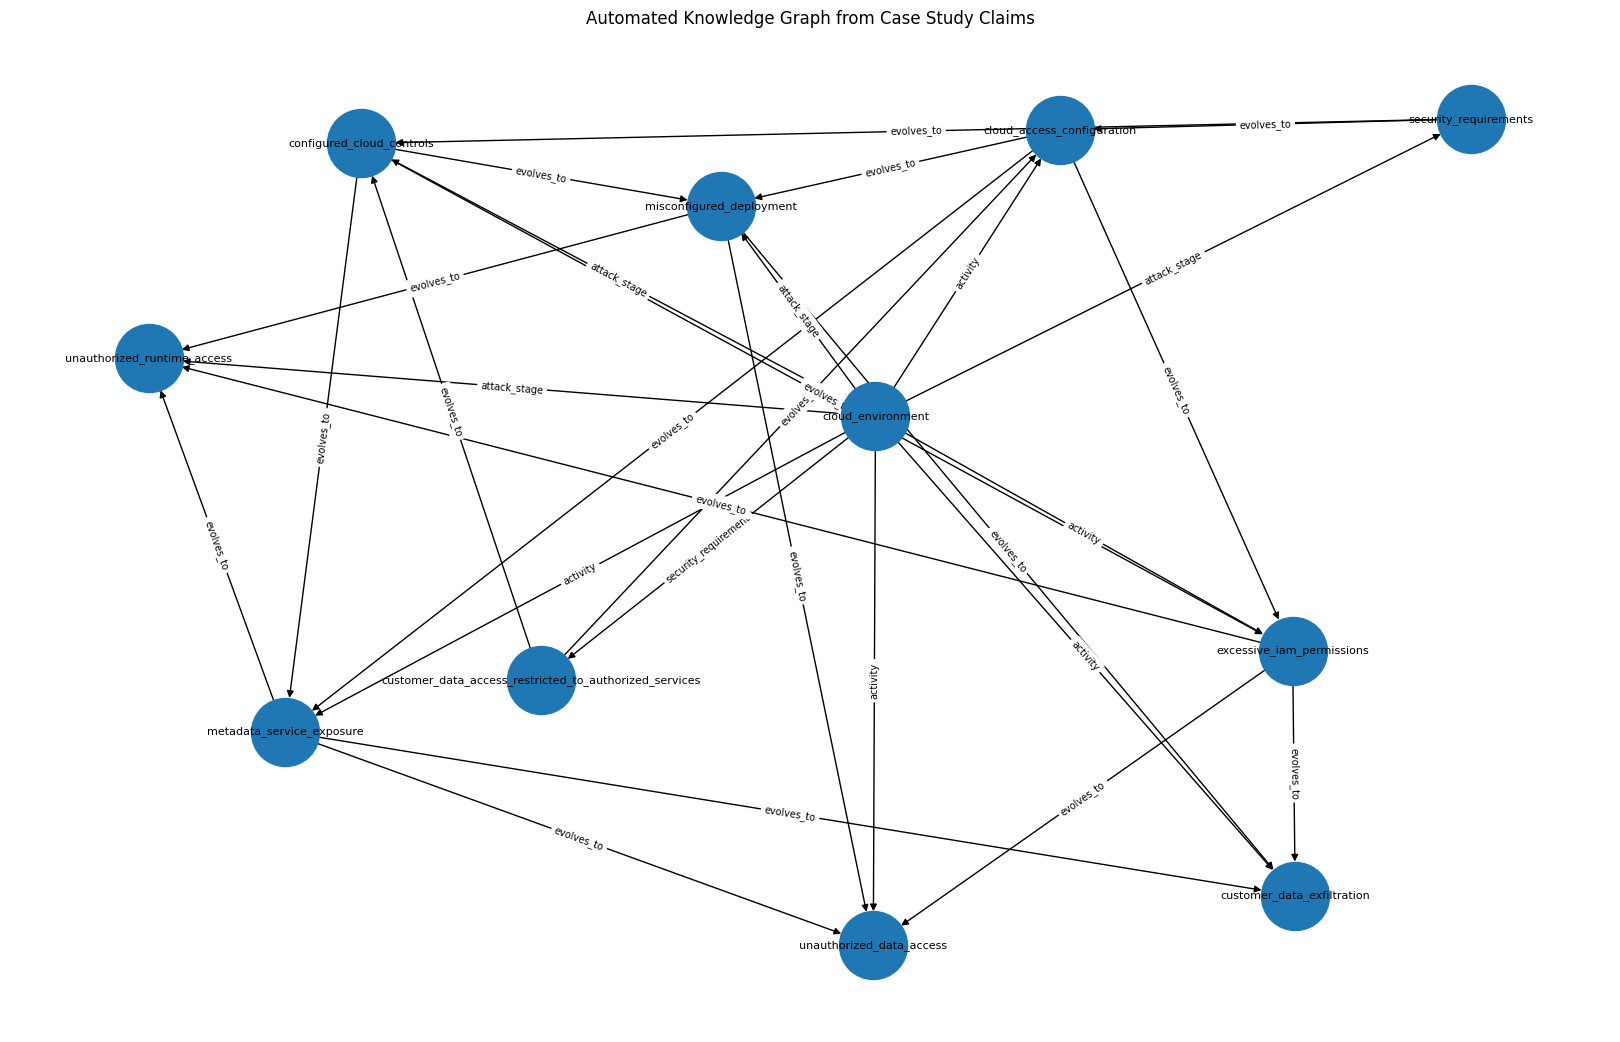

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

KG_auto = nx.DiGraph()

# Step 1: collect claims from each artifact/node
stage_claims = {}

for stage in G_case.nodes():
    claim_set = get_claims(G_case, stage)
    stage_claims[stage] = claim_set.claims

    for claim in claim_set.claims:
        KG_auto.add_edge(
            claim.s,
            claim.o,
            label=claim.p,
            source_stage=stage
        )

# Step 2: automatically connect concepts across the digital thread
ordered_stages = list(nx.topological_sort(G_case))

for i in range(len(ordered_stages) - 1):
    current_stage = ordered_stages[i]
    next_stage = ordered_stages[i + 1]

    current_objects = [c.o for c in stage_claims[current_stage]]
    next_objects = [c.o for c in stage_claims[next_stage]]

    for current_obj in current_objects:
        for next_obj in next_objects:
            if current_obj != next_obj:
                KG_auto.add_edge(
                    current_obj,
                    next_obj,
                    label="evolves_to",
                    from_stage=current_stage,
                    to_stage=next_stage
                )

# Step 3: draw the automated KG
plt.figure(figsize=(16, 10))

pos = nx.spring_layout(KG_auto, seed=42, k=1.8)

nx.draw(
    KG_auto,
    pos,
    with_labels=True,
    node_size=2400,
    font_size=8,
    arrows=True
)

edge_labels = nx.get_edge_attributes(KG_auto, "label")

nx.draw_networkx_edge_labels(
    KG_auto,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Automated Knowledge Graph from Case Study Claims")
plt.tight_layout()
plt.show()

In [ ]:
print("Nodes =", KG_auto.number_of_nodes())
print("Edges =", KG_auto.number_of_edges())

Nodes = 11
Edges = 29


In [ ]:
density = nx.density(KG_auto)
print(density)

0.2636363636363636


Produce a table for the paper

In [ ]:
import pandas as pd

rows = []
for e in events_case:
    rows.append({
        "Transition": f"{e.source} → {e.target}",
        "Constraint": e.constraint_id,
        "Severity": round(e.severity, 3),
        "Classification": e.drift_type,
        "Explanation": e.explanation
    })

df_case = pd.DataFrame(rows)
df_case

,Transition,Constraint,Severity,Classification,Explanation
0,Configuration → Deployment,SIC-CLOUD-001,0.575,emergent drift,SIC=SIC-CLOUD-001: Customer data must only be ...
1,Deployment → Runtime,SIC-CLOUD-001,0.732,policy-violating drift,SIC=SIC-CLOUD-001: Customer data must only be ...


Structured Drift, Embedding Drift, and Hybrid Score

In [ ]:
def score_transition_details(G: nx.DiGraph, src: str, dst: str, p: SIC):
    Ci = get_claims(G, src)
    Cj = get_claims(G, dst)
    delta = get_edge_delta(G, src, dst)

    Ci_p = select_claims(Ci, p)
    Cj_p = select_claims(Cj, p)
    scoped_delta = restrict_delta_to_scope(delta, p)

    D_structured = risk_weighted_structured_delta(scoped_delta, p, Cj_p)
    D_structured_hat = normalize_structured(D_structured, p)

    Ti = render_summary(Ci_p)
    Tj = render_summary(Cj_p)
    ei = _EMBEDDER.encode([Ti], normalize_embeddings=True)[0]
    ej = _EMBEDDER.encode([Tj], normalize_embeddings=True)[0]
    d_embed = float(1.0 - np.dot(ei, ej))
    D_embed_hat = calibrate_embed(d_embed, p)

    D_hybrid = float(p.lambda_p * D_structured_hat + (1.0 - p.lambda_p) * D_embed_hat)

    return D_structured_hat, D_embed_hat, D_hybrid

rows = []
p = P_case[0]
for src, dst in G_case.edges():
    s, e, h = score_transition_details(G_case, src, dst, p)
    rows.append({
        "Transition": f"{src} → {dst}",
        "Structured Drift": round(s, 3),
        "Embedding Drift": round(e, 3),
        "Hybrid Score": round(h, 3),
    })

df_scores = pd.DataFrame(rows)
df_scores

,Transition,Structured Drift,Embedding Drift,Hybrid Score
0,Requirements → Configuration,0.18,0.460,0.320
1,Configuration → Deployment,0.68,0.469,0.575
2,Deployment → Runtime,1.00,0.464,0.732


In [ ]:
ground_truth = {
    "Requirements → Configuration": "PASS",
    "Configuration → Deployment": "SUSPECT",
    "Deployment → Runtime": "VIOLATION"
}

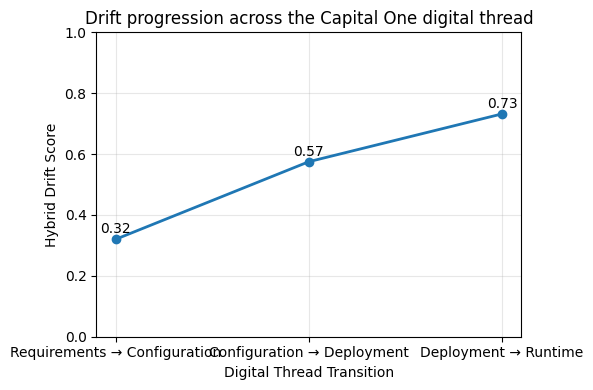

In [ ]:
transitions = df_scores["Transition"].tolist()
hybrid_scores = df_scores["Hybrid Score"].tolist()

plt.figure(figsize=(6,4))
plt.plot(transitions, hybrid_scores, marker='o', linewidth=2)

plt.ylim(0,1)
plt.ylabel("Hybrid Drift Score")
plt.xlabel("Digital Thread Transition")
plt.title("Drift progression across the Capital One digital thread")

for i, v in enumerate(hybrid_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("capitalone_drift_progression.png", dpi=300)
plt.show()

In [ ]:
def classify_from_score(score, epsilon=0.25):
    if score <= epsilon:
        return "PASS"
    elif score < 0.65:
        return "SUSPECT"
    else:
        return "VIOLATION"


rows = []

p = P_case[0]

for src, dst in G_case.edges():
    D_s, D_e, D_h = score_transition_details(G_case, src, dst, p)

    transition = f"{src} → {dst}"

    rows.append({
        "Transition": transition,
        "Ground Truth": ground_truth[transition],
        "Structured-only": classify_from_score(D_s, p.epsilon),
        "Embedding-only": classify_from_score(D_e, p.epsilon),
        "Full S3DT": classify_from_score(D_h, p.epsilon),
        "D_structured": round(D_s, 3),
        "D_embed": round(D_e, 3),
        "D_hybrid": round(D_h, 3),
    })

df_ablation = pd.DataFrame(rows)
df_ablation

,Transition,Ground Truth,Structured-only,Embedding-only,Full S3DT,D_structured,D_embed,D_hybrid
0,Requirements → Configuration,PASS,PASS,SUSPECT,SUSPECT,0.18,0.460,0.320
1,Configuration → Deployment,SUSPECT,VIOLATION,SUSPECT,SUSPECT,0.68,0.469,0.575
2,Deployment → Runtime,VIOLATION,VIOLATION,SUSPECT,VIOLATION,1.00,0.464,0.732


In [ ]:
methods = ["Structured-only", "Embedding-only", "Full S3DT"]

ablation_summary = []

for method in methods:
    correct = (df_ablation[method] == df_ablation["Ground Truth"]).sum()
    total = len(df_ablation)

    ablation_summary.append({
        "Method": method,
        "Correct": f"{correct}/{total}",
        "Accuracy": round(correct / total * 100, 1)
    })

df_ablation_summary = pd.DataFrame(ablation_summary)
df_ablation_summary

,Method,Correct,Accuracy
0,Structured-only,2/3,66.7
1,Embedding-only,1/3,33.3
2,Full S3DT,2/3,66.7
